<center><span style="font-size:60px;"><b>METRICS ANALYSIS</b></span></center>

In [1]:
# IMPORTS
import os
import math
import glob
import time
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt


# import torch
# import torchvision.transforms as T

We apply metrics to both whole image and hole-only patch. This is because with hole-only we evaluate the generated patch excluding the sorrounding frame (which is basically copied from grounf truth) while with the whole image we evaluate also the global consistency of the resulting image.

---

---

---

# LOAD RESULTS

In [2]:
# LOAD RESULTS
metrics_array = np.load("metrics_contextual_attention_inverted.npy")
mean_metrics = np.load("mean_metrics_contextual_attention_inverted_mask_only.npy", allow_pickle=True).item()

metric_names = ["L1", "PSNR", "SSIM", "LPIPS"]

In [3]:
metrics_array[:4,:9,2]  # debug

array([[0.65232474, 0.7812745 , 0.6506797 , 0.5388744 , 0.53883326,
        0.53840196, 0.48323888, 0.48427007, 0.48356518],
       [0.9107084 , 0.88121986, 0.9121574 , 0.83574677, 0.83457553,
        0.8318953 , 0.7750625 , 0.7751333 , 0.7758619 ],
       [0.7788869 , 0.7399796 , 0.78218573, 0.6586421 , 0.658455  ,
        0.6592448 , 0.58954966, 0.58609915, 0.5884637 ],
       [0.8696389 , 0.87763333, 0.8680436 , 0.7802032 , 0.78026664,
        0.78106964, 0.72693574, 0.72677827, 0.72771037]], dtype=float32)

In [4]:
mean_metrics  # debug

{'L1': 0.12917882204055786,
 'PSNR': 15.8787260055542,
 'SSIM': 0.8169928193092346,
 'LPIPS': 0.16924068331718445}

---

# MASK AND IMAGES ANALYSIS

In [5]:
def plot_metric_histograms(metrics_array, metric_names):
    """
    Plots histogram of each metric over all (image, mask) pairs.
    """

    N_metrics = metrics_array.shape[2]

    for k in range(N_metrics):
        values = metrics_array[:, :, k].flatten()

        plt.figure(figsize=(15,4))
        plt.hist(values, bins=70)
        plt.title(f"Distribution of {metric_names[k]}")
        plt.xlabel(metric_names[k])
        plt.ylabel("Frequency")
        plt.grid(alpha=0.4)
        plt.show()

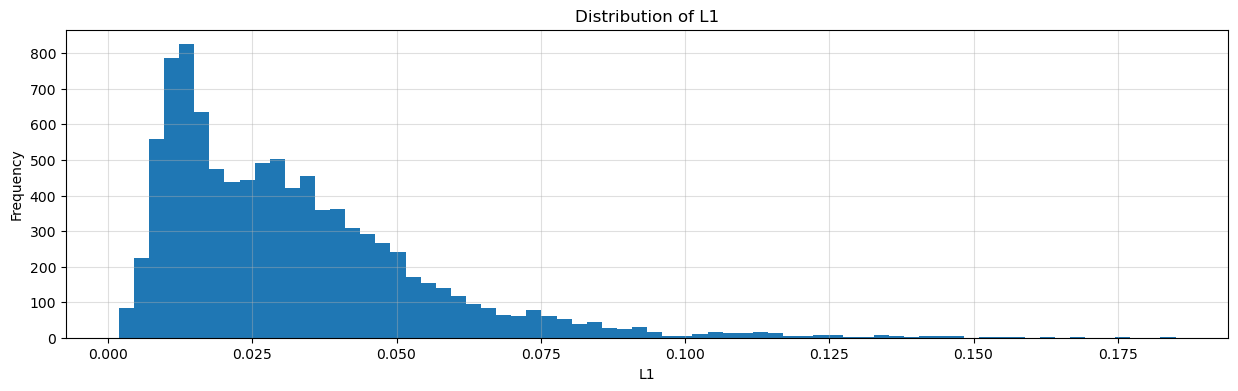

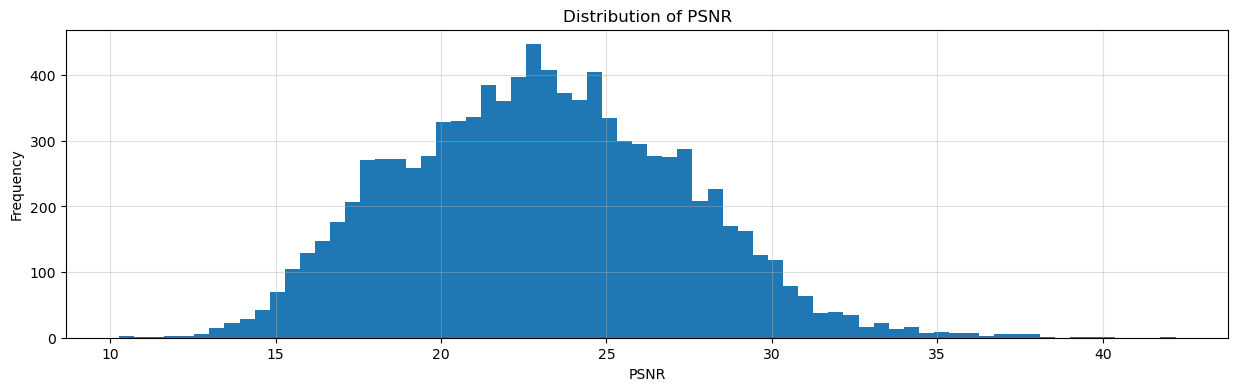

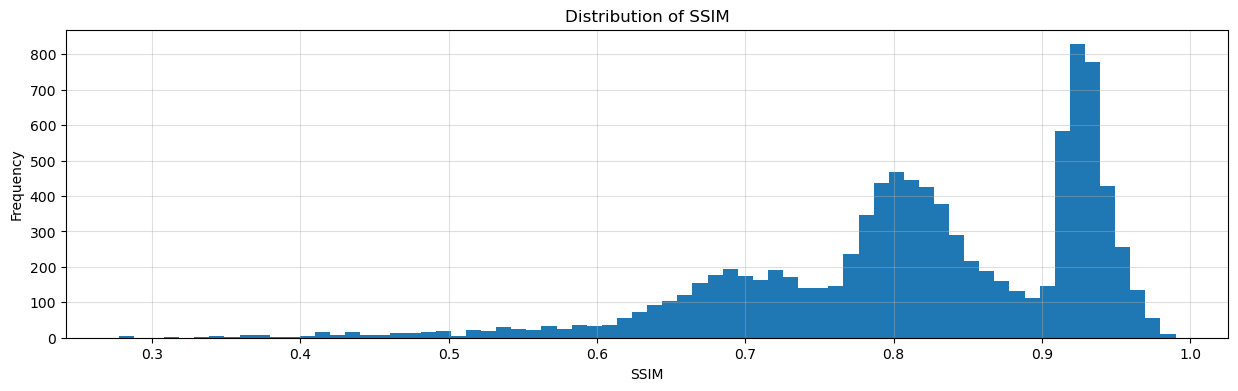

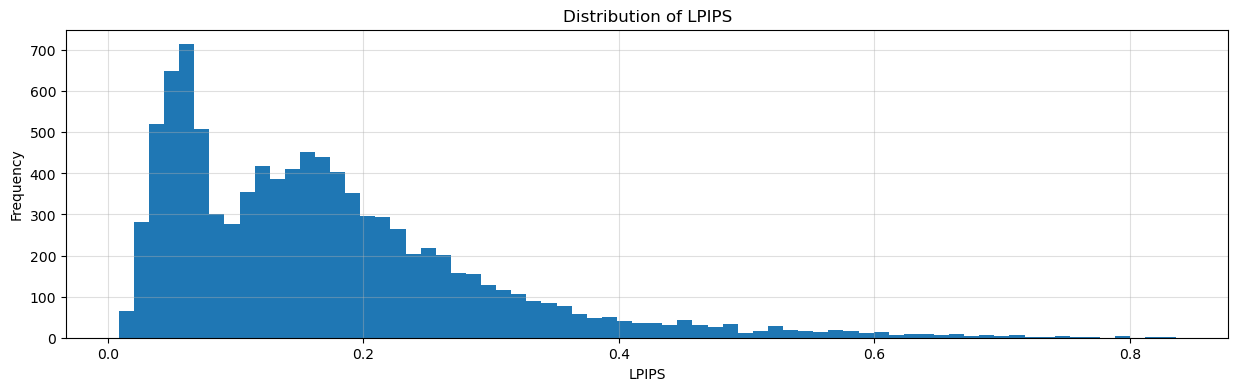

In [6]:
plot_metric_histograms(metrics_array, metric_names)

In [7]:
def plot_heatmap(metrics_array, metric_names):
    """
    Heatmap for each metric (images x masks) displayed in a two-column grid.
    """
    N_images, N_masks, num_metrics = metrics_array.shape
    cols = 2
    rows = math.ceil(num_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    
    # Flatten axes array for easy 1D iteration (handles 1D or 2D axes array)
    axes_flat = axes.flatten() if num_metrics > 1 else [axes]


    for k, name in enumerate(metric_names):
        ax = axes_flat[k]
        im = ax.imshow(metrics_array[:, :, k], aspect='auto')
        fig.colorbar(im, ax=ax, label=name)
        ax.set_title(f"{name} heatmap (images x masks)")
        ax.set_xlabel("Mask index")
        ax.set_ylabel("Image index")

    # Hide any unused subplots in the grid if num_metrics is odd
    for k in range(num_metrics, len(axes_flat)):
        fig.delaxes(axes_flat[k])

    plt.tight_layout()
    plt.show()

Let's search for:
* hard masks (vertical stripes)
* hard images (horizontal stripes)

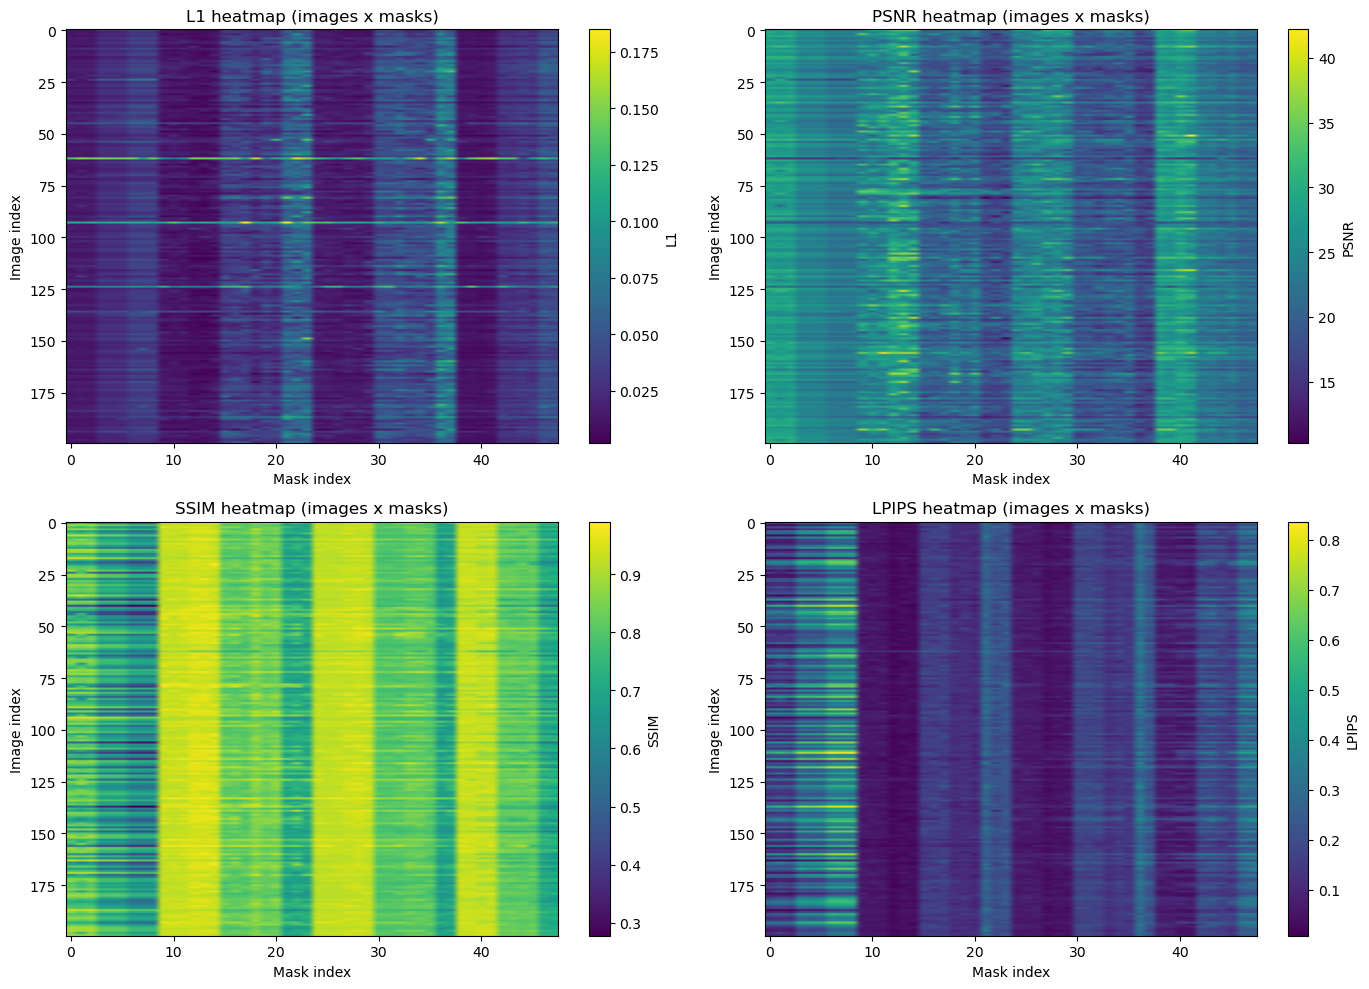

In [8]:
plot_heatmap(metrics_array, metric_names)

In [9]:
def plot_mask_difficulty(metrics_array, metric_names):
    """
    Average metric per mask in a 2-column layout.
    """
    mask_means = metrics_array.mean(axis=0)  # (M, K)
    
    num_metrics = len(metric_names)
    cols = 2
    rows = math.ceil(num_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)

    for k, name in enumerate(metric_names):
        r, c = divmod(k, cols)
        ax = axes[r, c]
        mask_index = [i+1 for i in range(len(mask_means[:, k]))]
        
        ax.plot(mask_index, mask_means[:, k], marker='o')
        ax.set_title(f"{name} vs Mask index")
        ax.set_xlabel("Mask index")
        ax.set_ylabel(name)
        ax.grid(True)

    # Hide unused subplots if the total count is odd
    for k in range(num_metrics, rows * cols):
        r, c = divmod(k, cols)
        axes[r, c].set_visible(False)

    plt.tight_layout()
    plt.show()

Search for hardest masks:

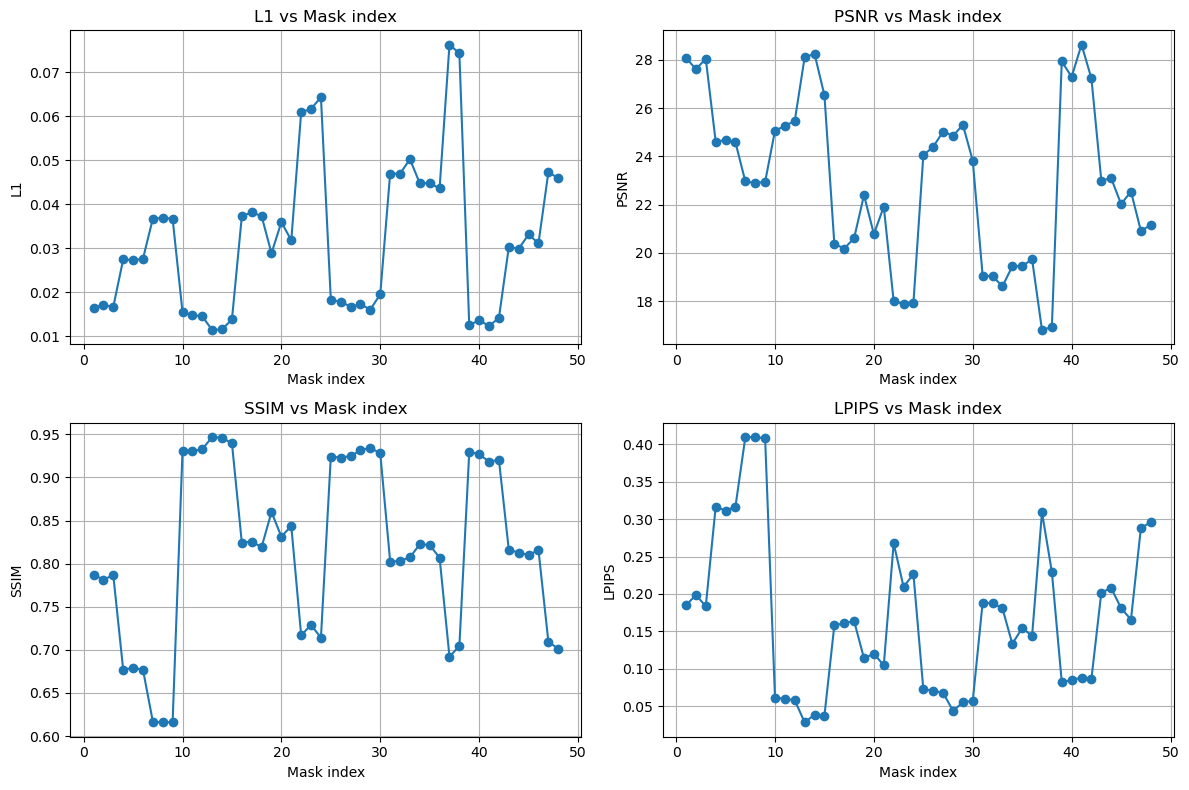

In [10]:
plot_mask_difficulty(metrics_array, metric_names)

In [11]:
def plot_image_difficulty(metrics_array, metric_names):
    """
    Average metric per image displayed in a two-column grid.
    """
    image_means = metrics_array.mean(axis=1)  # (N, K)
    num_metrics = len(metric_names)

    # Calculate required rows for a 2-column layout
    cols = 2
    rows = math.ceil(num_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    axes = axes.flatten()  # Flatten to a 1D array for easy iteration

    for k, name in enumerate(metric_names):
        img_index = [i+1 for i in range(len(image_means[:, k]))]
        ax = axes[k]
        ax.plot(img_index, image_means[:, k])
        ax.set_title(f"{name} vs Image index")
        ax.set_xlabel("Image index")
        ax.set_ylabel(name)
        ax.grid(True)

    # Hide any unused subplots if the metric count is odd
    for k in range(num_metrics, len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

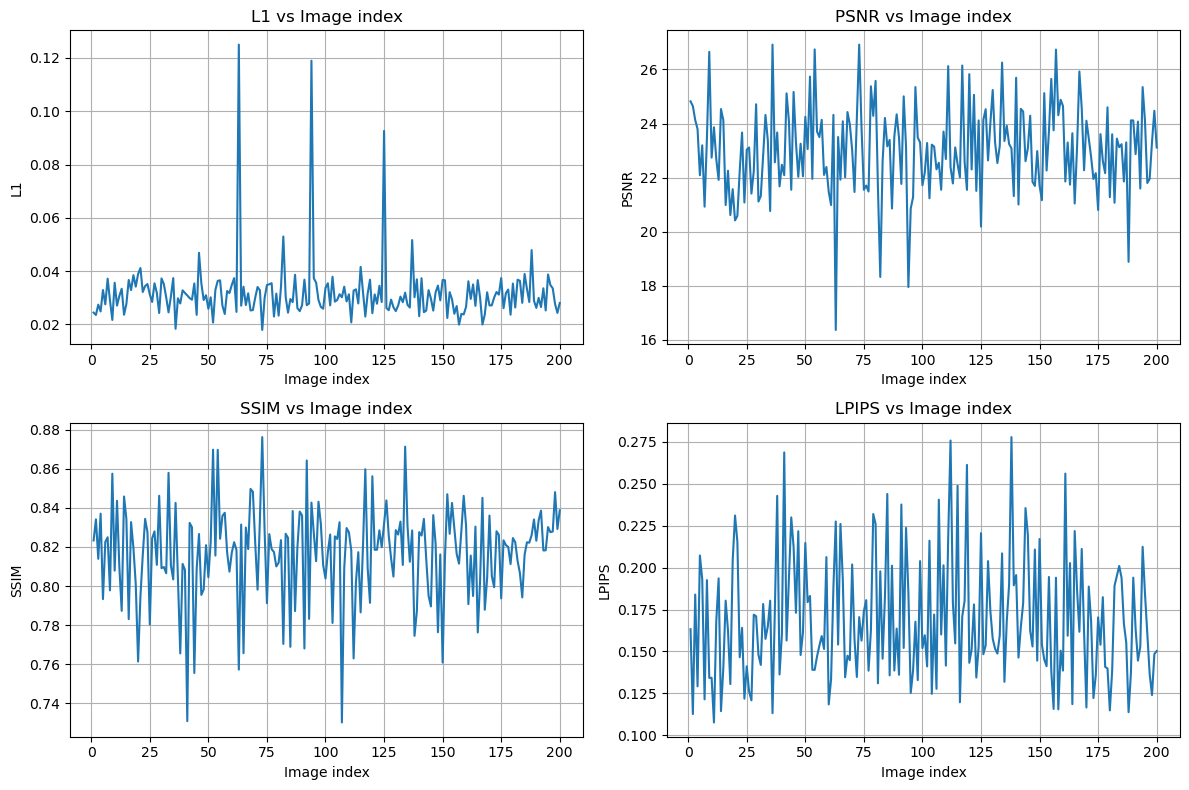

In [12]:
plot_image_difficulty(metrics_array, metric_names)

In [13]:
def find_extreme_cases(metrics_array, metric_names):
    """
    Finds min/max values and their (image, mask) positions.
    """

    results = {}

    for k, name in enumerate(metric_names):
        metric_values = metrics_array[:, :, k]

        min_idx = metric_values.argmin()
        max_idx = metric_values.argmax()

        min_pos = np.unravel_index(min_idx, metric_values.shape)
        max_pos = np.unravel_index(max_idx, metric_values.shape)

        results[name] = {
            "min_value": metric_values[min_pos],
            "min_pos": min_pos,
            "max_value": metric_values[max_pos],
            "max_pos": max_pos,
        }

    return results

In [14]:
results = find_extreme_cases(metrics_array, metric_names)
results

{'L1': {'min_value': 0.0018504225,
  'min_pos': (156, 13),
  'max_value': 0.18501727,
  'max_pos': (93, 17)},
 'PSNR': {'min_value': 10.258505,
  'min_pos': (81, 21),
  'max_value': 42.201313,
  'max_pos': (51, 41)},
 'SSIM': {'min_value': 0.27749035,
  'min_pos': (137, 7),
  'max_value': 0.99017775,
  'max_pos': (20, 14)},
 'LPIPS': {'min_value': 0.008543037,
  'min_pos': (20, 14),
  'max_value': 0.8358616,
  'max_pos': (111, 6)}}

In [15]:
def rank_masks(metrics_array, metric_index):
    """
    Returns masks sorted by difficulty.
    """

    mask_means = metrics_array.mean(axis=0)[:, metric_index]

    sorted_idx = np.argsort(mask_means)

    return sorted_idx, mask_means

In [16]:
sorted_idx, mask_means = rank_masks(metrics_array, 0)
sorted_idx

array([12, 13, 40, 38, 39, 14, 41, 11, 10,  9, 28,  0,  2, 26,  1, 27, 25,
       24, 29,  4,  3,  5, 18, 43, 42, 45, 20, 44, 19,  8,  6,  7, 15, 17,
       16, 35, 33, 34, 47, 31, 30, 46, 32, 21, 22, 23, 37, 36])

In [17]:
def rank_images(metrics_array, metric_index):
    """
    Returns images sorted by difficulty.
    """

    image_means = metrics_array.mean(axis=1)[:, metric_index]

    sorted_idx = np.argsort(image_means)

    return sorted_idx, image_means

In [18]:
sorted_idx, image_means = rank_images(metrics_array, 0)
sorted_idx

array([ 72,  35, 156, 166,  51, 110,   8, 151, 116,  77, 139,  79,   1,
        44,  13, 178, 167, 158,  56, 157, 154, 119,  28, 198,  83,   0,
        32, 141,  61,   3,  88, 129, 145, 142,  67, 193, 126,  68,  49,
        98, 175,  87, 125, 189, 135, 180, 128, 191, 159,  97, 155, 163,
        55,  63, 130,  10, 169, 101, 170,  89,  91,  65, 134,   2,   5,
        14, 197, 121,  92,  37, 113, 199, 183, 132,  85, 123, 186,  25,
       103, 108, 188,   7, 148,  47,  96, 104,  42, 127, 153,  84, 161,
       144,  36,  41,  73, 190, 165,  69, 171,  31,  50, 106, 137,  82,
       131,  33,  11,  40,  48, 173,  24, 120, 109, 105, 117,  78,  66,
       176,  58,  39,  27, 133, 146, 168, 152, 172,  21, 115,  57, 111,
        71,  38,  16, 143,   4,  52, 177, 112, 185,  12, 192, 196,  99,
        70,  80,  64,  18, 107,  22, 122, 147, 195,  74,  59, 162,  75,
        30,  23, 179,  43,  26,  46, 100,  76,   9,  95, 160,  53, 182,
        54, 150, 164,  15, 149, 181, 118,  90, 138,   6,  29, 14

In [19]:
def image_variance(metrics_array, metric_index):
    """
    Variance across masks for each image.
    """
    var = metrics_array[:, :, metric_index].var(axis=1)

    return var

High variance = model struggles depending on mask\
Low variance = robust image

In [20]:
image_variance(metrics_array, 0)[0:10]

array([0.0002678 , 0.00018834, 0.00038343, 0.00021594, 0.00040162,
       0.00024451, 0.00046313, 0.00034616, 0.0002111 , 0.00022496],
      dtype=float32)

In [21]:
def mask_variance(metrics_array, metric_index):
    """
    Variance across images for each mask.
    """
    var = metrics_array[:, :, metric_index].var(axis=0)

    return var

In [22]:
mask_variance(metrics_array, 0)[0:10]

array([0.00016626, 0.00018276, 0.00018044, 0.00015823, 0.00016009,
       0.00016043, 0.00016714, 0.00013399, 0.00015332, 0.00016784],
      dtype=float32)

---

---

---

# GROUP ANALYSIS

Final masks variety for iizuka
* 1-3: sap, ratio 0.1 (too sparse pixel to differentiate center-border)
* 4-6: sap, ratio 0.25 (too sparse pixel to differentiate center-border)
* 7-9: sap, ratio 0.4 (too sparse pixel to differentiate center-border)
* 10-12: box, ratio 0.1, centered
* 13-15: box, ratio 0.1, bordered
* 16-18: box, ratio 0.25, centered
* 19-21: box, ratio 0.25, bordered
* 22: box, ratio 0.4, centered
* 23-24: box, ratio 0.4, bordered
* 25-27: circle, ratio 0.1, centered
* 28-30: circle, ratio 0.1, bordered
* 31-33: circle, ratio 0.25, centered
* 34-36: circle, ratio 0.25, bordered
* 37: circle, ratio 0.4, centered
* 38: circle, ratio 0.4, bordered
* 39-40: rw, ratio 0.1, centered
* 41-42: rw, ratio 0.1, bordered
* 43-44: rw, ratio 0.25, centered
* 45-46: rw, ratio 0.25, bordered
* 47-48: rw, ratio 0.4 (too sparse pixel to differentiate center-border)

In [23]:
def build_mask_dataframe(zero_indexed=True):
    """
    Builds structured metadata for masks.

    Each mask has:
        - method (sap, box, circle, rw)
        - ratio (0.1, 0.25, 0.4)
        - position (center, border, None)

    Returns:
        pandas DataFrame with one row per mask
        
    Put zero_indexed=False if you want the index to start from 1 (like the masks names)
    """
    
    # Format: (start, end, method, ratio, position)
    rules = [
        (1, 3, "sap", 0.1, "global"),
        (4, 6, "sap", 0.25, "global"),
        (7, 9, "sap", 0.4, "global"),
        (10, 12, "box", 0.1, "center"),
        (13, 15, "box", 0.1, "border"),
        (16, 18, "box", 0.25, "center"),
        (19, 21, "box", 0.25, "border"),
        (22, 22, "box", 0.4, "center"),
        (23, 24, "box", 0.4, "border"),
        (25, 27, "circle", 0.1, "center"),
        (28, 30, "circle", 0.1, "border"),
        (31, 33, "circle", 0.25, "center"),
        (34, 36, "circle", 0.25, "border"),
        (37, 37, "circle", 0.4, "center"),
        (38, 38, "circle", 0.4, "border"),
        (39, 40, "rw", 0.1, "center"),
        (41, 42, "rw", 0.1, "border"),
        (43, 44, "rw", 0.25, "center"),
        (45, 46, "rw", 0.25, "border"),
        (47, 48, "rw", 0.4, "global"),
    ]

    data = []
    for start, end, method, ratio, pos in rules:
        for i in range(start, end + 1):
            data.append({
                "mask_id": i - 1 if zero_indexed else i,
                "method": method,
                "ratio": ratio,
                "position": pos
            })

    return pd.DataFrame(data)

In [24]:
# create dataframes for masks
mask_df = build_mask_dataframe(zero_indexed=False)
print(mask_df.head())

   mask_id method  ratio position
0        1    sap   0.10   global
1        2    sap   0.10   global
2        3    sap   0.10   global
3        4    sap   0.25   global
4        5    sap   0.25   global


In [25]:
def metrics_to_df(metrics_array, mask_df, metric_names):
    """
    Converts (N_images, N_masks, N_metrics)
    into a long-form pandas DataFrame.

    Each row = (image, mask, metric values + metadata)
    """

    N_img, N_mask, N_metrics = metrics_array.shape

    rows = []

    for i in range(N_img):
        for j in range(N_mask):

            row = {
                "image_id": i+1,
                "mask_id": j
            }

            # add metrics
            for k, name in enumerate(metric_names):
                row[name] = metrics_array[i, j, k]

            # add metadata
            meta = mask_df.iloc[j].to_dict()
            row.update(meta)

            rows.append(row)

    return pd.DataFrame(rows)

In [26]:
df = metrics_to_df(metrics_array, mask_df, metric_names)
print(f"dataframe length (N_images * N_masks) = {df.shape[0]}")
df.head(10)

dataframe length (N_images * N_masks) = 9600


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
0,1,1,0.017370,26.076498,0.652325,0.206753,sap,0.10,global
1,1,2,0.013378,27.726608,0.781274,0.148910,sap,0.10,global
2,1,3,0.017520,25.987967,0.650680,0.199191,sap,0.10,global
3,1,4,0.032488,22.492247,0.538874,0.332890,sap,0.25,global
4,1,5,0.032195,22.558231,0.538833,0.339076,sap,0.25,global
5,1,6,0.032487,22.487392,0.538402,0.331087,sap,0.25,global
6,1,7,0.045446,20.786325,0.483239,0.430444,sap,0.40,global
7,1,8,0.045421,20.778454,0.484270,0.420164,sap,0.40,global
8,1,9,0.045248,20.794991,0.483565,0.428799,sap,0.40,global
9,1,10,0.013687,23.582880,0.930412,0.056089,box,0.10,center


In [27]:
def plot_metric_vs_ratio(df, metrics=("L1", "PSNR", "SSIM", "LPIPS")):
    """
    Shows how metrics evolve with hole ratio.
    Grouped by method and position.
    """

    for metric in metrics:
        plt.figure(figsize=(10, 5))

        sns.lineplot(
            data=df,
            x="ratio",
            y=metric,
            hue="method",
            style="position",
            #errorbar="sd",
            marker="o"
        )

        plt.title(f"{metric} vs Ratio")
        plt.grid(True)
        plt.show()

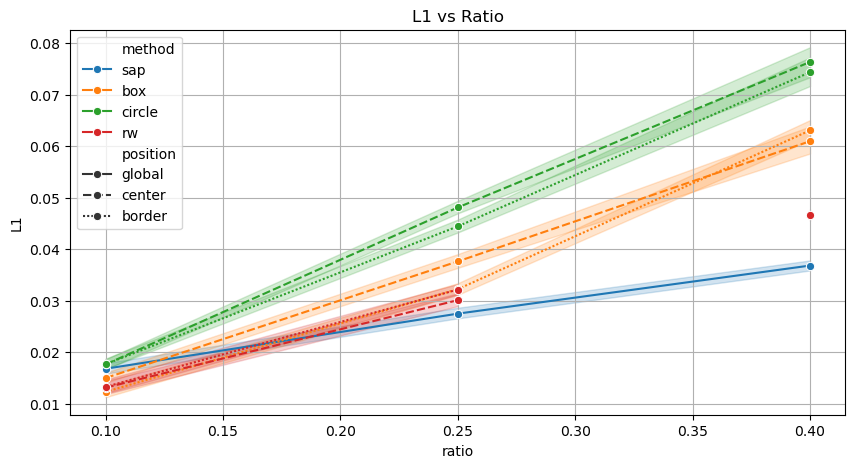

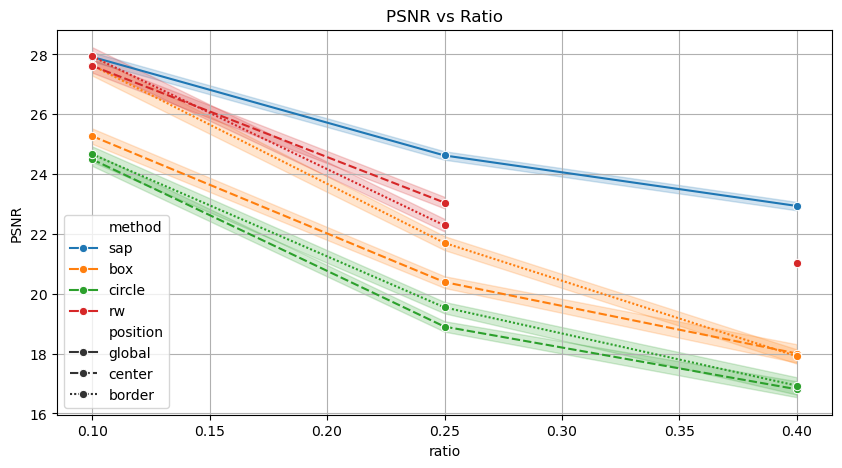

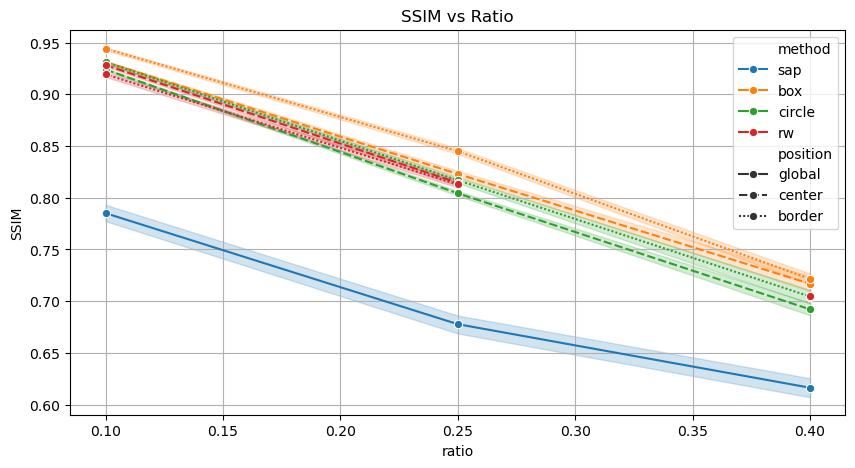

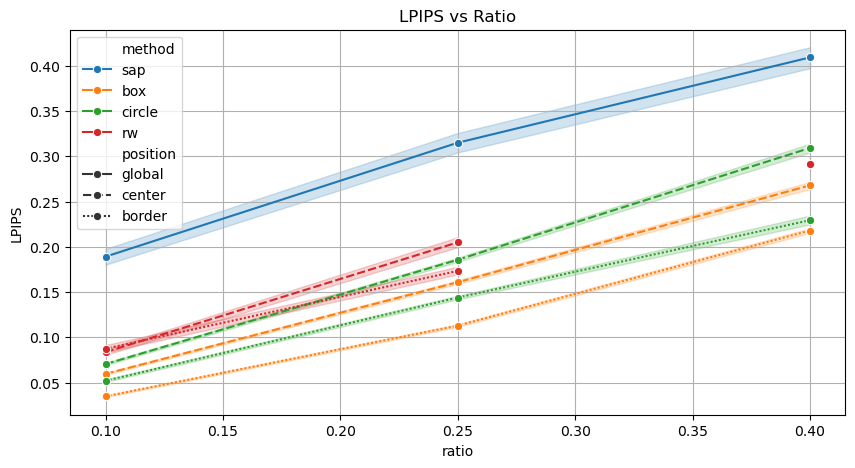

In [28]:
plot_metric_vs_ratio(df, metric_names)

Performance worsen as ratio increases as expected.
Not much difference between border and center methods up to 25% masking, while for 40% border performs better -> Less semantic meaning in the borders of the images, which are likely to get masked in the border setting, so it is easier to reconstruct the image.

In [29]:
def plot_method_comparison(df, metrics=("L1", "PSNR", "SSIM", "LPIPS")):
    """
    Compares methods globally (averaged over ratio + position) arranged in 2 columns.
    """
    num_metrics = len(metrics)
    cols = 2
    rows = math.ceil(num_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    
    # Ensure axes is a 1D or 2D array even if single row/col
    axes = axes.flatten() if num_metrics > 1 else [axes]

    for i, metric in enumerate(metrics):
        sns.barplot(
            data=df,
            x="method",
            y=metric,
            errorbar="sd",
            ax=axes[i]
        )
        axes[i].set_title(f"{metric} by Method")
        axes[i].grid(alpha=0.3)

    # Hide any unused subplots if the number of metrics is odd
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

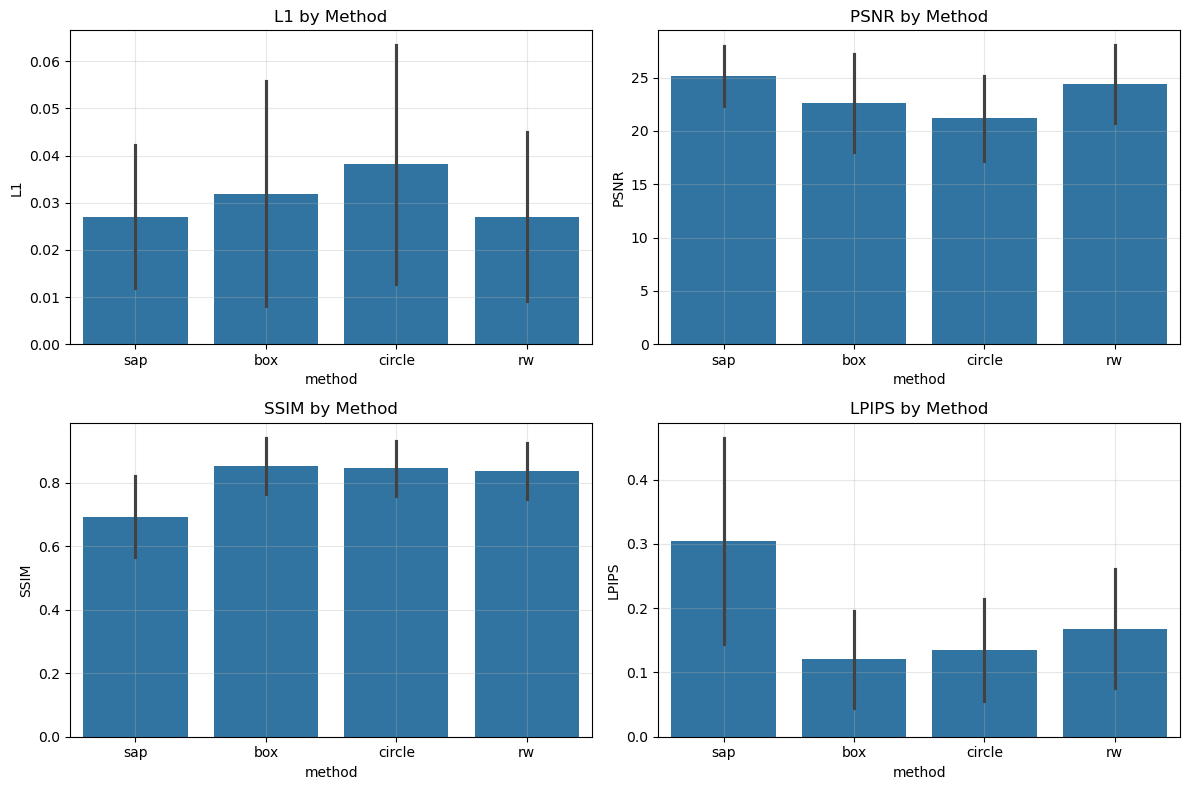

In [30]:
plot_method_comparison(df, metric_names)

Overall, rw performs the best (easier to reconstruct)

In [31]:
def plot_position_effect(df, metrics=("L1", "PSNR", "SSIM", "LPIPS")):
    """Compares centered vs border masks in a 2-column grid layout."""
    n_metrics = len(metrics)
    cols = 2
    rows = int(np.ceil(n_metrics / cols))

    fig, axes = plt.subplots(
        rows, cols, figsize=(12, 4 * rows), squeeze=False
    )

    filtered_df = df[df["position"] != "global"]

    for idx, metric in enumerate(metrics):
        r, c = divmod(idx, cols)
        ax = axes[r, c]

        sns.barplot(
            data=filtered_df,
            x="position",
            y=metric,
            hue="method",
            errorbar="sd",
            ax=ax,
        )

        ax.set_title(f"{metric}: Center vs Border")
        ax.grid(True)

    # Hide any unused subplots (if an odd number of metrics is provided)
    for idx in range(n_metrics, rows * cols):
        r, c = divmod(idx, cols)
        fig.delaxes(axes[r, c])

    plt.tight_layout()
    plt.show()

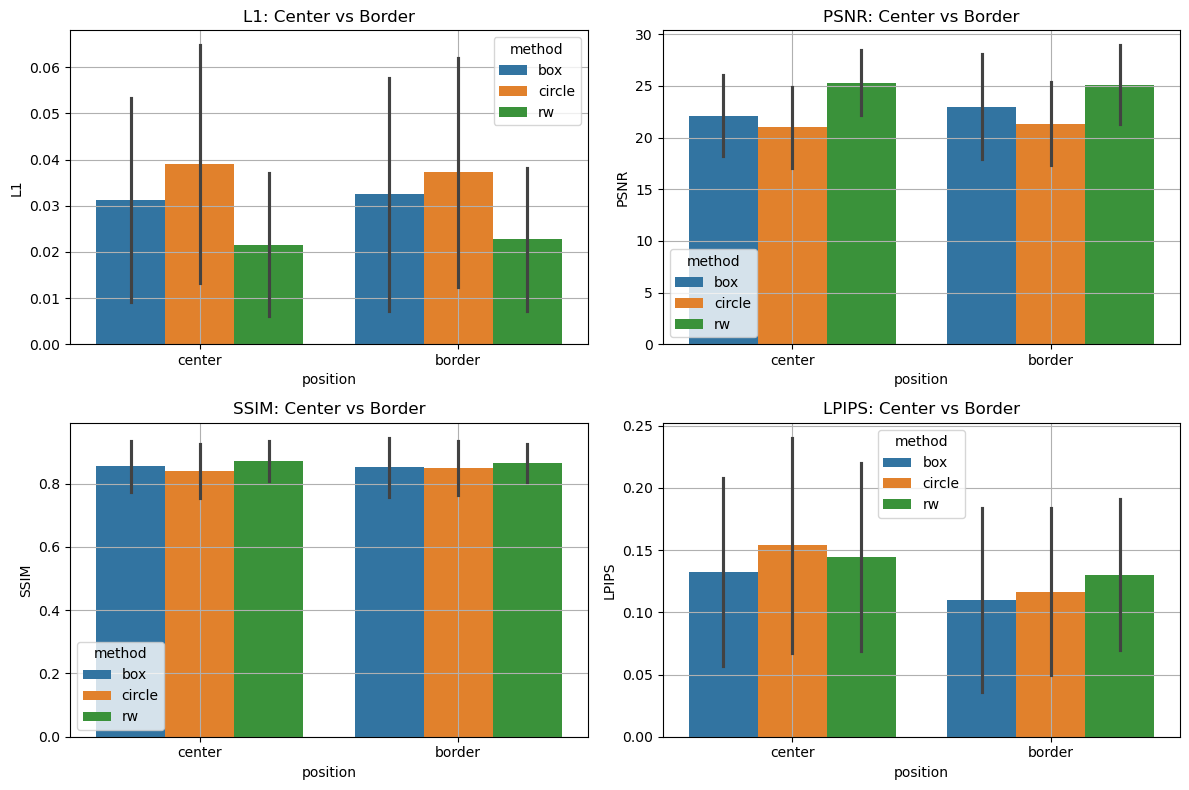

In [32]:
plot_position_effect(df, metric_names)

In [33]:
def plot_method_ratio_heatmap(df, metrics=["L1"]):
    """
    Heatmaps: method vs ratio averaged over images for a list of metrics in 2 columns.
    """
    n_metrics = len(metrics)
    cols = 2
    rows = math.ceil(n_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        pivot = df.pivot_table(
            values=metric,
            index="method",
            columns="ratio",
            aggfunc="mean"
        )
        sns.heatmap(pivot, annot=True, cmap="viridis", ax=axes[i])
        axes[i].set_title(f"{metric}: Method vs Ratio")

    # Hide any unused subplots (if n_metrics is odd)
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

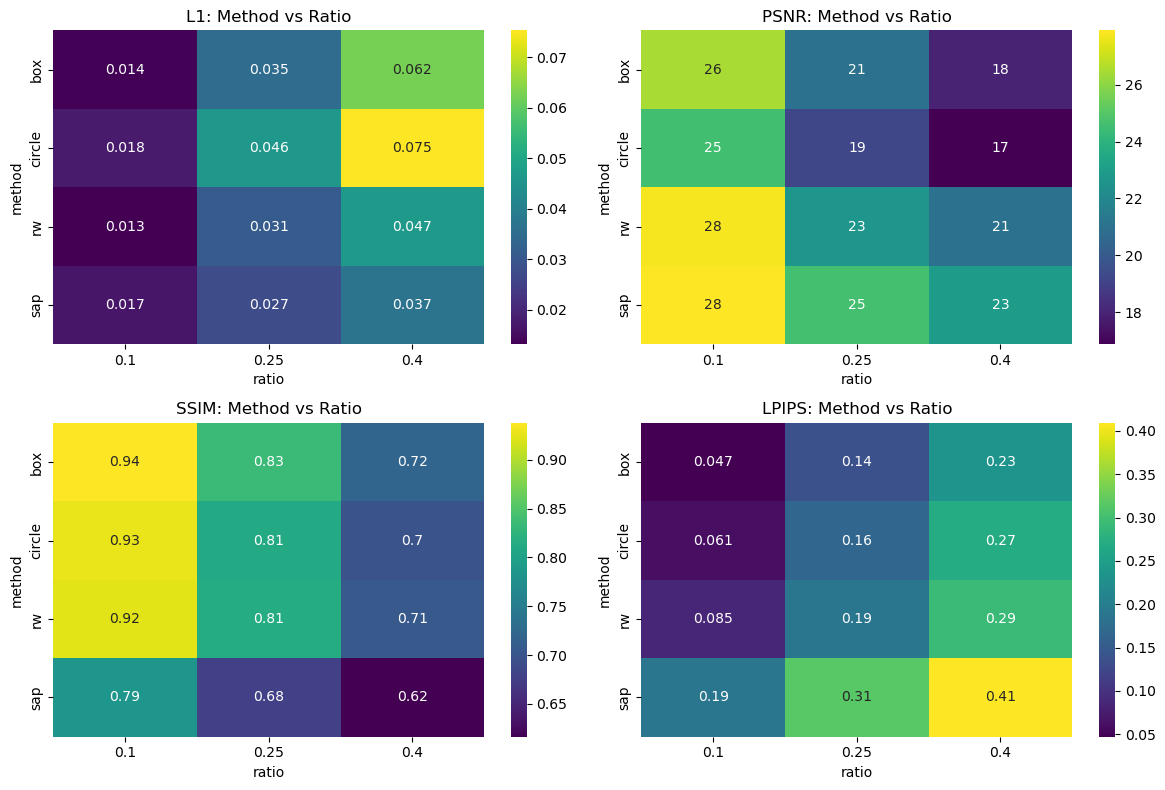

In [34]:
plot_method_ratio_heatmap(df, metric_names)

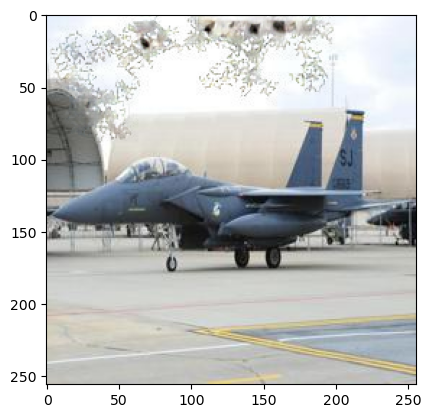

In [36]:
import os
from PIL import Image

def get_image_filepath(parent_dir: str, test_id: int, mask_id: int) -> str:
    filename = f"Places365_test_{test_id:08d}__{mask_id:06d}.png"
    return os.path.join(parent_dir, filename)

conv_results = "/home/mattia/Downloads/ContextAttentionOutput/content/ContextAttentionOutput"
gt_path = "/home/mattia/Downloads/PlacesTestSet"

# Example Usage:
full_path = get_image_filepath(conv_results, 161, 42)
img = Image.open(full_path)
plt.imshow(img)

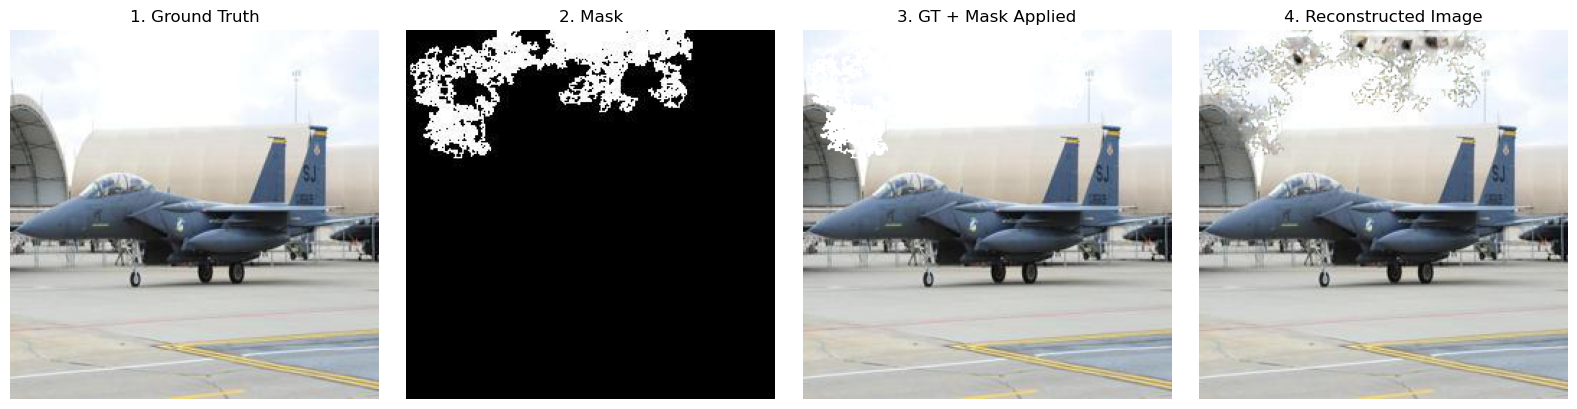

In [37]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def visualize_inpainting_results(
    reconstructed_dir: str,
    gt_dir: str,
    mask_dir: str,
    test_id: int,
    mask_id: int
):
    # 1. Construct file paths according to their respective naming schemes
    gt_path = os.path.join(gt_dir, f"Places365_test_{test_id:08d}.jpg")
    mask_path = os.path.join(mask_dir, f"{mask_id:06d}.jpg")
    rec_path = os.path.join(reconstructed_dir, f"Places365_test_{test_id:08d}__{mask_id:06d}.png")
    
    # Verify all files exist
    paths = {"Ground Truth": gt_path, "Mask": mask_path, "Reconstructed": rec_path}
    for name, path in paths.items():
        if not os.path.exists(path):
            print(f"Error: {name} file not found at '{path}'")
            return
            
    # 2. Load Ground Truth and Reconstructed images
    gt_img = Image.open(gt_path).convert("RGB")
    rec_img = Image.open(rec_path).convert("RGB")
    
    # 3. Load Mask and convert to boolean array
    mask_img = Image.open(mask_path).convert("L")
    mask_bool = np.array(mask_img) > 128  # True where defect/hole is located
    
    # 4. Create Ground Truth with Mask Applied (Defected Image)
    gt_np = np.array(gt_img)
    defect_np = gt_np.copy()
    defect_np[mask_bool] = 255  # 0 for mask in black, 255 for mask in white
    
    # 5. Plot all four side-by-side in a single row
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(gt_img)
    axes[0].set_title("1. Ground Truth")
    
    axes[1].imshow(mask_img, cmap="gray")
    axes[1].set_title("2. Mask")
    
    axes[2].imshow(defect_np)
    axes[2].set_title("3. GT + Mask Applied")
    
    axes[3].imshow(rec_img)
    axes[3].set_title("4. Reconstructed Image")
    
    for ax in axes:
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

net_results = "/home/mattia/Downloads/ContextAttentionOutput/content/ContextAttentionOutput"
gt_path = "/home/mattia/Downloads/PlacesTestSet"
mask_path = "/home/mattia/Desktop/PhysicsOfData/Vision/FinalResults/masks_inverted"
# Example usage:
visualize_inpainting_results(
    reconstructed_dir=net_results,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=161,
    mask_id=42
)

In [38]:
print("-------------Min L1-------------:")
display(df.sort_values(by = "L1", ascending = True).head(3))
print("-------------Min LPIPS-------------:")
display(df.sort_values(by = "LPIPS", ascending = True).head(3))
print("-------------Max PSNR-------------:")
display(df.sort_values(by = "PSNR", ascending = False).head(3))
print("-------------Max SSIM-------------:")
display(df.sort_values(by = "SSIM", ascending = False).head(3))

-------------Min L1-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
7501,157,14,0.001850,37.418732,0.982023,0.022956,box,0.1,border
974,21,15,0.001889,36.838165,0.990178,0.008543,box,0.1,border
2489,52,42,0.001989,42.201313,0.977367,0.085183,rw,0.1,border


-------------Min LPIPS-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
974,21,15,0.001889,36.838165,0.990178,0.008543,box,0.1,border
1933,41,14,0.003412,34.379101,0.973782,0.009219,box,0.1,border
6684,140,13,0.004184,34.609589,0.969002,0.009776,box,0.1,border


-------------Max PSNR-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
2489,52,42,0.001989,42.201313,0.977367,0.085183,rw,0.1,border
7499,157,12,0.002290,40.348152,0.982034,0.016260,box,0.1,center
6061,127,14,0.002300,39.619221,0.973547,0.022249,box,0.1,border


-------------Max SSIM-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
974,21,15,0.001889,36.838165,0.990178,0.008543,box,0.1,border
6397,134,14,0.014631,33.970264,0.986279,0.034802,box,0.1,border
6686,140,15,0.002554,37.902065,0.983500,0.027729,box,0.1,border


In [39]:
import pandas as pd
from typing import Optional, List, Union

def display_top_k_metrics(
    df: pd.DataFrame,
    column: str,
    ascending: Optional[bool] = None,
    k: int = 3,
    filter_query: Optional[str] = None
) -> pd.DataFrame:
    """
    Filters a DataFrame and displays the top K rows sorted by a specified column.
    Automatically infers whether to minimize (L1, LPIPS, MSE, etc.) or 
    maximize (PSNR, SSIM, etc.).
    
    Parameters:
    -----------
    df : pd.DataFrame
        The input database/DataFrame.
    column : str
        The column name to sort by (e.g., 'L1', 'LPIPS', 'PSNR', 'SSIM').
    ascending : bool, optional
        If provided (True/False), overrides the automatic inference.
        If None, automatically inferred from the column name.
    k : int, default 3
        Number of top rows to display.
    filter_query : str, optional
        A pandas query string to filter the dataset before sorting 
        (e.g., "test_id == 1" or "mask_id in [18, 20]").
        
    Returns:
    --------
    pd.DataFrame
        The filtered and sorted top K rows.
    """
    filtered_df = df.copy()
    
    # 1. Infer ascending direction if not explicitly provided
    if ascending is None:
        # Error / distance metrics to minimize (ascending=True)
        minimize_metrics = {'l1', 'lpips', 'mse', 'rmse', 'mae', 'fid'}
        
        # Quality / similarity metrics to maximize (ascending=False)
        maximize_metrics = {'psnr', 'ssim', 'ms-ssim', 'uqi', 'vif'}
        
        col_lower = column.strip().lower()
        if col_lower in minimize_metrics:
            ascending = True
        elif col_lower in maximize_metrics:
            ascending = False
        else:
            # Default fallback for unknown metrics: assume lower is better
            ascending = True

    # 2. Apply optional filter if provided
    if filter_query:
        filtered_df = filtered_df.query(filter_query)
        
    # 3. Sort and get top K rows
    top_k_df = filtered_df.sort_values(by=column, ascending=ascending).head(k)
    
    # 4. Format and display header text
    mode_label = "Min" if ascending else "Max"
    filter_label = f" (Filtered: '{filter_query}')" if filter_query else ""
    
    print(f"-------------{mode_label} {column}{filter_label}-------------:")
    display(top_k_df)
    
    return top_k_df
box_l1 = display_top_k_metrics(df[df["method"] == "box"], "L1")

-------------Min L1-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
7501,157,14,0.001850,37.418732,0.982023,0.022956,box,0.1,border
974,21,15,0.001889,36.838165,0.990178,0.008543,box,0.1,border
7693,161,14,0.002209,37.332832,0.974813,0.023075,box,0.1,border


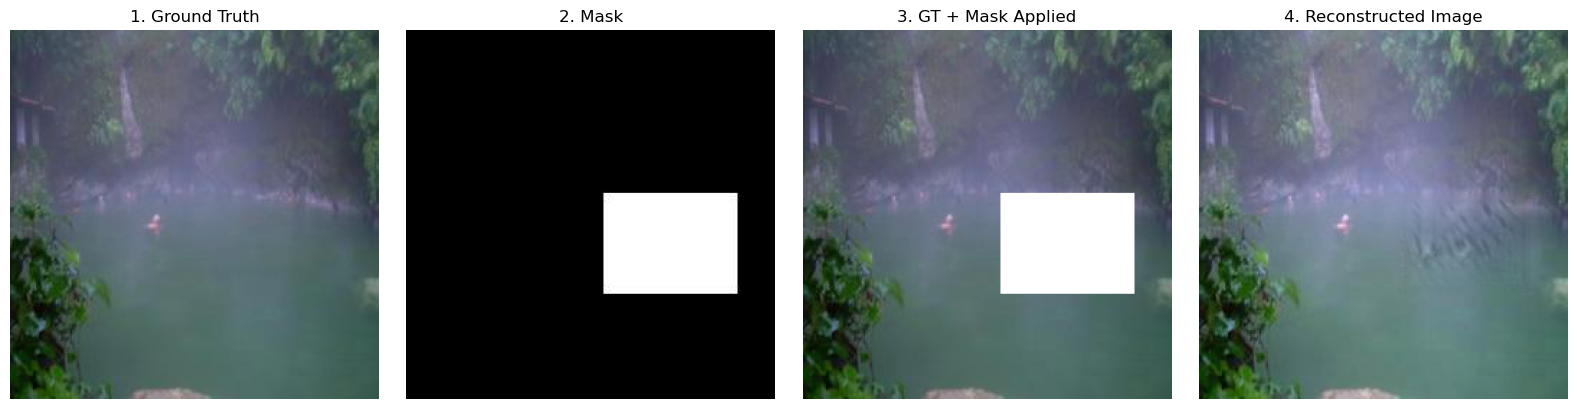

In [40]:
visualize_inpainting_results(
    reconstructed_dir=net_results,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=125,
    mask_id=11
)

# + IDEA: CORRELATIONS BETWEEN METRICS?

In [149]:
def paper_plot(
    reconstructed_dir: str,
    gt_dir: str,
    mask_dir: str,
    test_id: int,
    mask_id: int
):
    # 1. Construct file paths according to their respective naming schemes
    gt_path = os.path.join(gt_dir, f"Places365_test_{test_id:08d}.jpg")
    mask_path = os.path.join(mask_dir, f"{mask_id:06d}.jpg")
    rec_path = os.path.join(reconstructed_dir, f"Places365_test_{test_id:08d}__{mask_id:06d}.png")
    
    # Verify all files exist
    paths = {"Ground Truth": gt_path, "Mask": mask_path, "Reconstructed": rec_path}
    for name, path in paths.items():
        if not os.path.exists(path):
            print(f"Error: {name} file not found at '{path}'")
            return
            
    # 2. Load Ground Truth and Reconstructed images
    gt_img = Image.open(gt_path).convert("RGB")
    rec_img = Image.open(rec_path).convert("RGB")
    
    # 3. Load Mask and convert to boolean array
    mask_img = Image.open(mask_path).convert("L")
    mask_bool = np.array(mask_img) > 128  # True where defect/hole is located
    
    # 4. Create Ground Truth with Mask Applied (Defected Image)
    gt_np = np.array(gt_img)
    defect_np = gt_np.copy()
    defect_np[mask_bool] = 255  # 0 for mask in black, 255 for mask in white
    
    # 5. Plot all four side-by-side in a single row
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
    
    axes[0].imshow(gt_img)
    axes[0].set_title("Ground Truth")
    
    axes[1].imshow(defect_np)
    axes[1].set_title("GT + Mask Applied")
    
    axes[2].imshow(rec_img)
    axes[2].set_title("Reconstructed Image")
    
    for ax in axes:
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

In [42]:
box_l1 = display_top_k_metrics(df, column = "SSIM", k = 5, filter_query = "method == 'box'")

-------------Max SSIM (Filtered: 'method == 'box'')-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
974,21,15,0.001889,36.838165,0.990178,0.008543,box,0.1,border
6397,134,14,0.014631,33.970264,0.986279,0.034802,box,0.1,border
6686,140,15,0.002554,37.902065,0.983500,0.027729,box,0.1,border
7499,157,12,0.002290,40.348152,0.982034,0.016260,box,0.1,center
7501,157,14,0.001850,37.418732,0.982023,0.022956,box,0.1,border


In [43]:
box_l1 = display_top_k_metrics(df, column = "L1", k = 5, filter_query = "method == 'sap'")

-------------Min L1 (Filtered: 'method == 'sap'')-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
1681,36,2,0.006666,33.804649,0.952190,0.020521,sap,0.1,global
385,9,2,0.008811,32.480503,0.868318,0.080810,sap,0.1,global
6049,127,2,0.008844,31.751547,0.880925,0.107752,sap,0.1,global
3456,73,1,0.008887,31.573608,0.863349,0.185984,sap,0.1,global
3458,73,3,0.009032,31.410564,0.860609,0.190046,sap,0.1,global


In [44]:
box_l1 = display_top_k_metrics(df, column = "L1", k = 5, filter_query = "method == 'rw'")

-------------Min L1 (Filtered: 'method == 'rw'')-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
2489,52,42,0.001989,42.201313,0.977367,0.085183,rw,0.1,border
5609,117,42,0.002435,39.027290,0.974608,0.057847,rw,0.1,border
5608,117,41,0.002910,37.447609,0.963476,0.074639,rw,0.1,border
4265,89,42,0.003139,34.385189,0.969441,0.072909,rw,0.1,border
425,9,42,0.003431,36.366714,0.966593,0.031522,rw,0.1,border


In [45]:
box_l1 = display_top_k_metrics(df, column = "PSNR", k = 5, filter_query = "method == 'circle'")

-------------Max PSNR (Filtered: 'method == 'circle'')-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
9289,194,26,0.003896,35.989296,0.957272,0.045844,circle,0.1,center
9288,194,25,0.004145,35.714272,0.956084,0.059484,circle,0.1,center
1564,33,29,0.004072,34.473858,0.974534,0.046367,circle,0.1,border
3484,73,29,0.004504,34.211658,0.970654,0.036700,circle,0.1,border
7517,157,30,0.004866,34.103302,0.976599,0.038315,circle,0.1,border


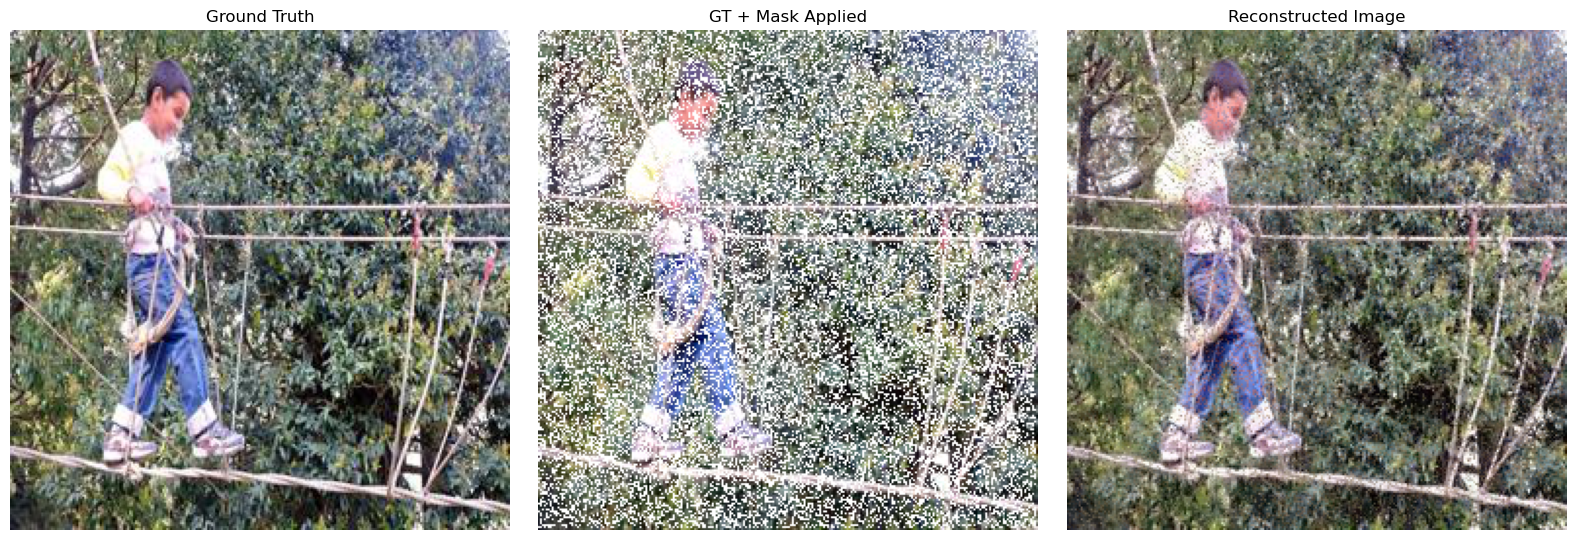

In [119]:
# Good SAP
paper_plot(
    reconstructed_dir=net_results,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=95,
    mask_id=9
)

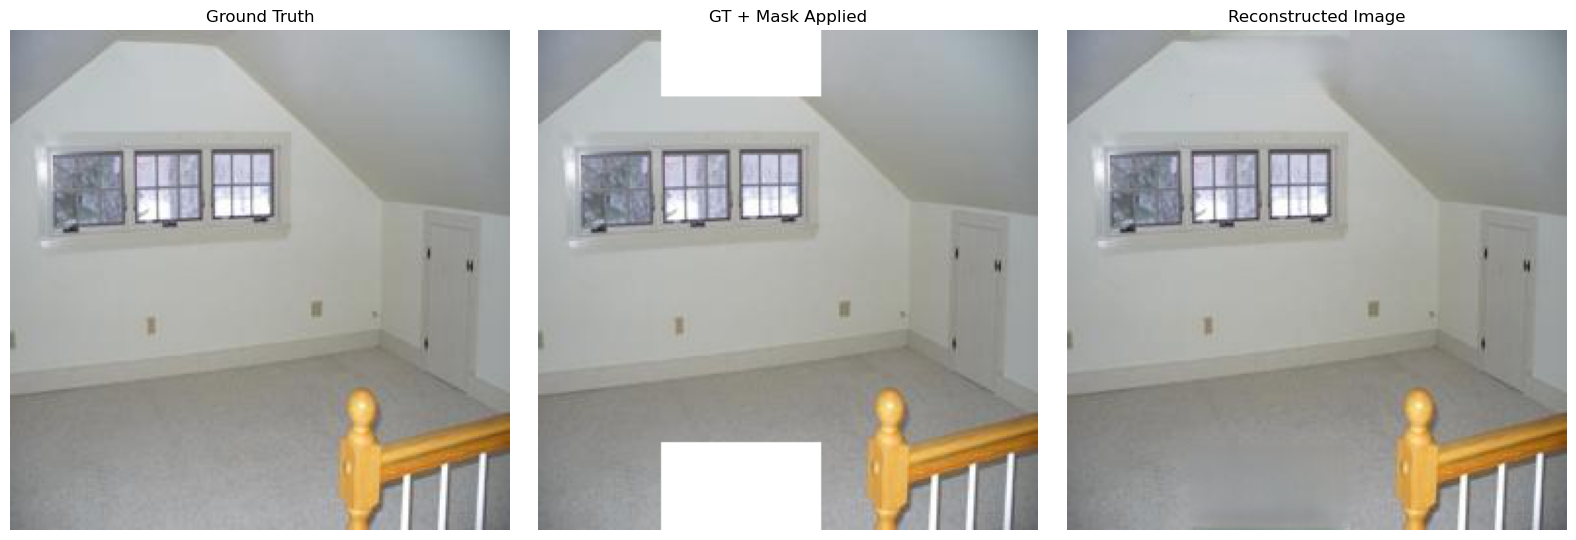

In [61]:
# Good box
paper_plot(
    reconstructed_dir=net_results,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=134,
    mask_id=14
)

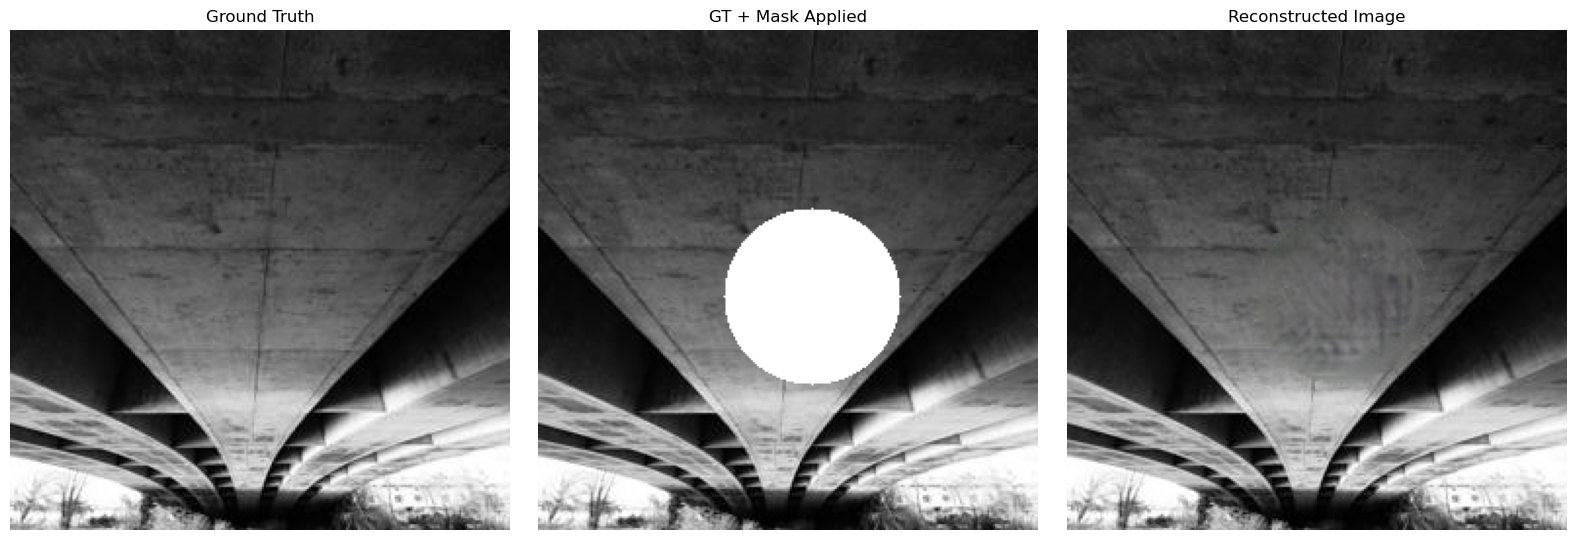

In [70]:
# Good circle
paper_plot(
    reconstructed_dir=net_results,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=194,
    mask_id=26
)

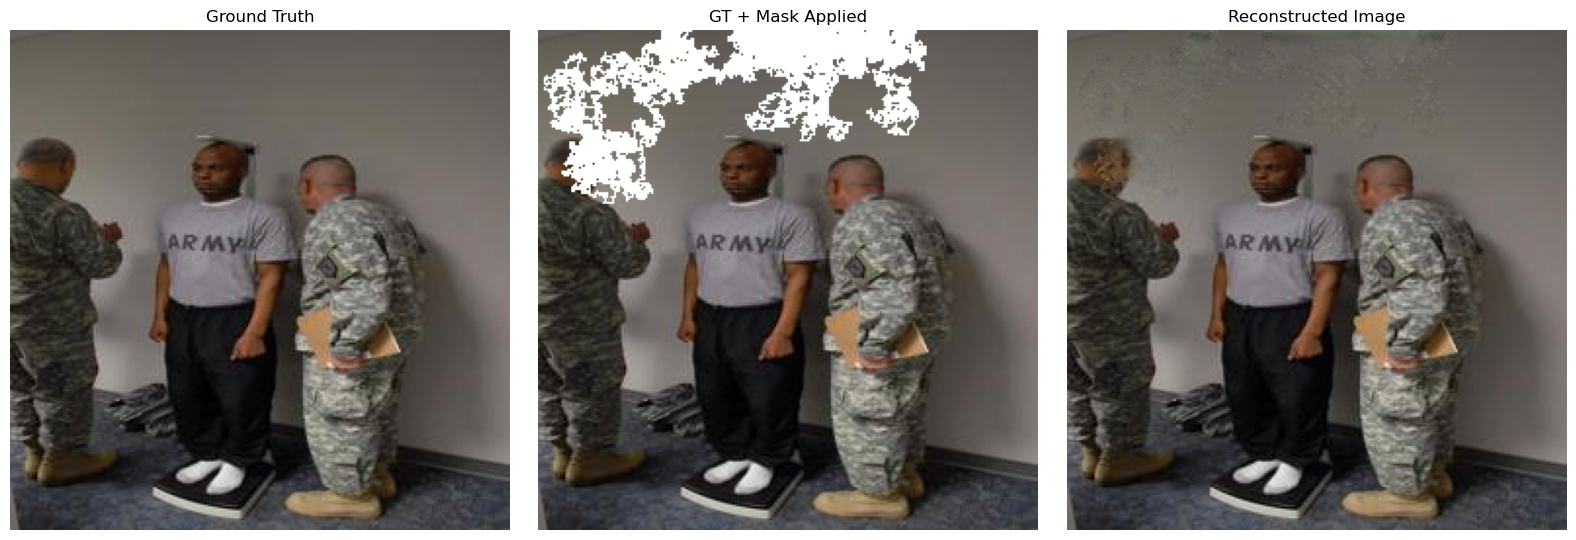

In [83]:
# Good rw
paper_plot(
    reconstructed_dir=net_results,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=117,
    mask_id=42
)

In [84]:
box_l1 = display_top_k_metrics(df, column = "L1", k = 5, filter_query = "method == 'box' and ratio > 0.1")

-------------Min L1 (Filtered: 'method == 'box' and ratio > 0.1')-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
7986,167,19,0.005775,35.638767,0.909120,0.081114,box,0.25,border
1794,38,19,0.006435,33.084148,0.918496,0.067040,box,0.25,border
8178,171,19,0.006875,34.105461,0.948355,0.088445,box,0.25,border
3474,73,19,0.007655,32.552689,0.931746,0.101248,box,0.25,border
7988,167,21,0.007720,33.377541,0.895714,0.071892,box,0.25,border


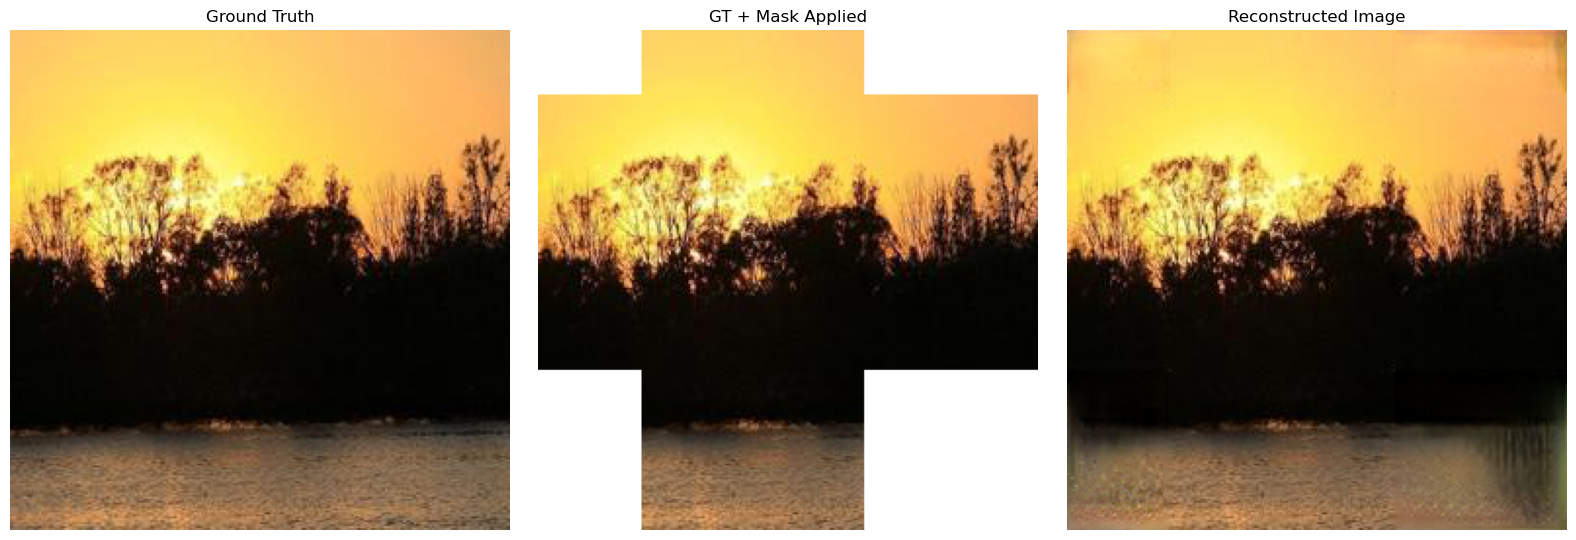

In [90]:
paper_plot(
    reconstructed_dir=net_results,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=38,
    mask_id=21
)

In [141]:
box_l1 = display_top_k_metrics(df, column = "LPIPS", k = 5, filter_query = "method == 'circle' and ratio > 0.3")

-------------Min LPIPS (Filtered: 'method == 'circle' and ratio > 0.3')-------------:


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
9493,198,38,0.051131,19.514328,0.742978,0.154969,circle,0.4,border
4405,92,38,0.040517,22.089052,0.834509,0.165913,circle,0.4,border
5605,117,38,0.035523,21.655663,0.825507,0.166041,circle,0.4,border
2773,58,38,0.067370,16.708366,0.727130,0.166617,circle,0.4,border
805,17,38,0.062612,17.339226,0.785729,0.170869,circle,0.4,border


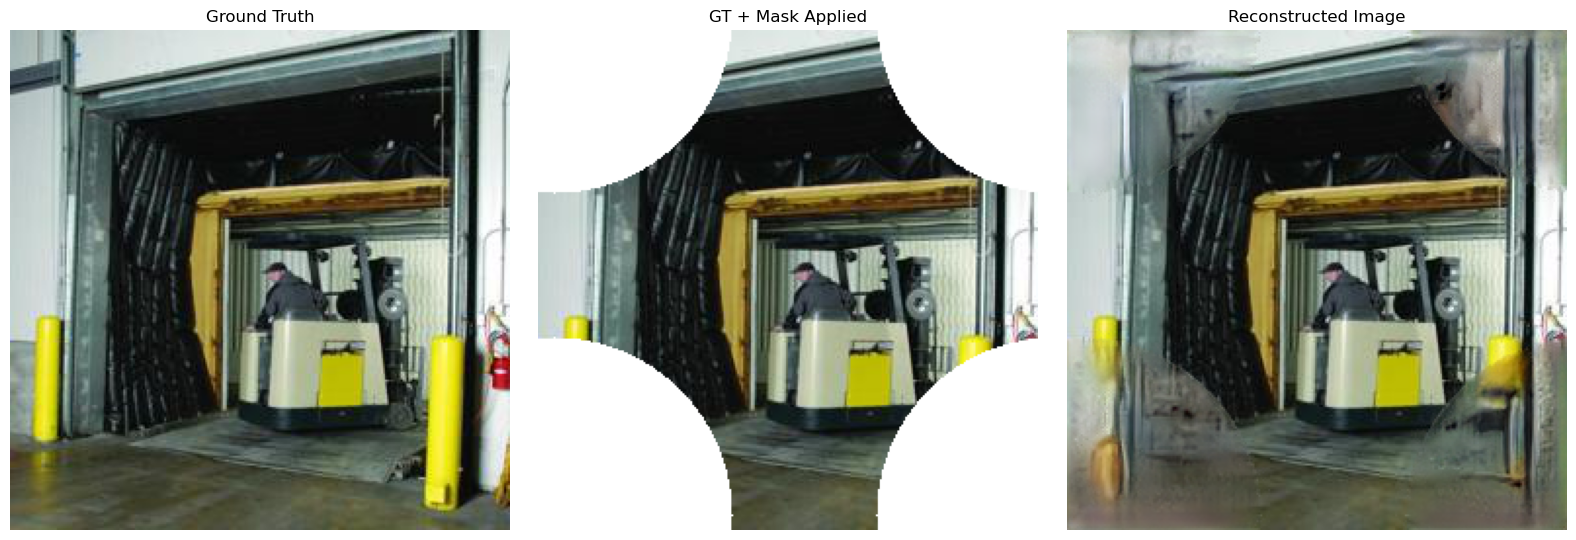

In [146]:
paper_plot(
    reconstructed_dir=net_results,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=58,
    mask_id=38
)

In [148]:
def paper_plot_all(
    reconstructed_dir: str,
    gt_dir: str,
    mask_dir: str,
    test_ids: Union[int, List[int]],
    mask_ids: Union[int, List[int]],
    savename
):
    # Ensure inputs are lists for uniform processing
    if isinstance(test_ids, int):
        test_ids = [test_ids]
    if isinstance(mask_ids, int):
        mask_ids = [mask_ids]

    # Validate that both lists are of equal length
    if len(test_ids) != len(mask_ids):
        raise ValueError(
            f"Length mismatch: test_ids ({len(test_ids)}) and mask_ids ({len(mask_ids)}) must have the same length."
        )

    n_rows = len(test_ids)

    # Initialize a figure with N rows and 3 columns
    # squeeze=False guarantees 'axes' is always a 2D array even if N=1
    fig_width = 3.2
    fig_height = 1.05 * n_rows + 0.3  # Dynamic height according to row count
    fig, axes = plt.subplots(
        n_rows,
        3,
        figsize=(fig_width, fig_height),
        squeeze=False,
        gridspec_kw={"wspace": 0.03, "hspace": 0.05},
    )

    for i, (t_id, m_id) in enumerate(zip(test_ids, mask_ids)):
        # 1. Construct file paths
        gt_path = os.path.join(gt_dir, f"Places365_test_{t_id:08d}.jpg")
        mask_path = os.path.join(mask_dir, f"{m_id:06d}.jpg")
        rec_path = os.path.join(
            reconstructed_dir, f"Places365_test_{t_id:08d}__{m_id:06d}.png"
        )

        # Verify all files exist for the current pair
        paths = {
            "Ground Truth": gt_path,
            "Mask": mask_path,
            "Reconstructed": rec_path,
        }
        for name, path in paths.items():
            if not os.path.exists(path):
                print(
                    f"Error: {name} file not found at '{path}' (Pair index {i})"
                )
                plt.close(fig)
                return

        # 2. Load images
        gt_img = Image.open(gt_path).convert("RGB")
        rec_img = Image.open(rec_path).convert("RGB")
        mask_img = Image.open(mask_path).convert("L")

        # 3. Apply mask to Ground Truth
        mask_bool = np.array(mask_img) > 128
        gt_np = np.array(gt_img)
        defect_np = gt_np.copy()
        defect_np[mask_bool] = 255

        # 4. Plot current row
        axes[i, 0].imshow(gt_img)
        axes[i, 1].imshow(defect_np)
        axes[i, 2].imshow(rec_img)

        # Set column titles only for the very first row
        if i == 0:
            axes[i, 0].set_title("Ground Truth", fontsize=7, pad=3)
            axes[i, 1].set_title("GT with Mask", fontsize=7, pad=3)
            axes[i, 2].set_title("Inpainted Output", fontsize=7, pad=3)

        # Turn off axis labels for all subplots in this row
        for ax in axes[i]:
            ax.axis("off")
    
    #plt.tight_layout()
    plt.savefig(savename, dpi=300, bbox_inches="tight")
    plt.show()

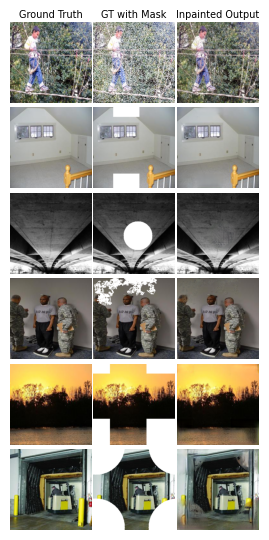

In [150]:
paper_plot_all(
    reconstructed_dir=net_results,
    gt_dir = gt_path,
    mask_dir = mask_path,
    test_ids = [95, 134, 194, 117, 38, 58],
    mask_ids = [9, 14, 26, 42, 21, 38],
    savename = "PAttentionQResults.png"
)